# **Facial Expression Recognition System**

### import the dataset

In [2]:
import kagglehub

path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fer2013' dataset.
Path to dataset files: /kaggle/input/fer2013


In [3]:
# os is a python library that helps interact with all the files and the folders
import os

# listdir(path)- shows everything stored inside path
print(os.listdir(path))

#train - dataset we'll use to train the model
#test - dataset we use to check how correctly the model is working

['test', 'train']


### load the training images

In [4]:
# tensorflow is a python library that helps train a model
import tensorflow as tf


#keras - a part of tensor library that is a machine learning pipeline used to train models
#.utils - a utilities or a helper function
# image_dataset_from_library - make a image datset from the directory that tensorflow can use in model trainig

train_data = tf.keras.utils.image_dataset_from_directory(

    path + "/train",
    # go to train folder in the dataset stored in path

    image_size =(48,48),

    color_mode="grayscale",

    batch_size=32
)

Found 28709 files belonging to 7 classes.


### load the testing images

In [5]:
test_data = tf.keras.utils.image_dataset_from_directory(
    path + "/test",
    image_size=(48, 48),
    color_mode="grayscale",
    batch_size=32
)

Found 7178 files belonging to 7 classes.


In [6]:
# check the data

print(test_data.class_names)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


### look at what's inside train data

In [7]:
for images , labels in train_data.take(1):
  print(images.shape)
  print(labels.shape)

(32, 48, 48, 1)
(32,)


### take 9 faces from our dataset and display themin a 3*3 grid with their emotions written above their faces

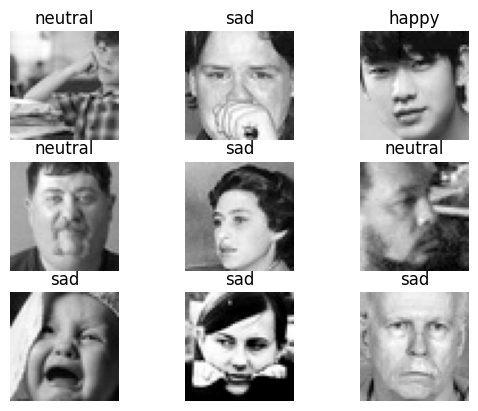

In [8]:
import matplotlib.pyplot as plt

for images, labels in train_data.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.title(train_data.class_names[labels[i]])
        plt.axis("off")

plt.show()


### Normalise the numbers

In [9]:
# in grayscale the images are made of numbers ranging from 0 to 255 so we normalise it
# keras stores all the data
# layers helps to access different layers of keras as in this instant - rescaling

normalisation_layer  = tf.keras.layers.Rescaling(1./255)

### CNN

In [10]:
# build an empty model using keras' sequential that makes a model layer by layer

model = tf.keras.Sequential()

In [12]:
# now we start filling the model

model.add(normalisation_layer)

# now an image enters so it becomes 48*48 then rescaling then value comes between 0-1 and then it is added to the model

In [14]:
# we use layers to access the kera layer Conv2D that is Convolutional Layer i.e. actual CNN
# in CNN model we add 32 filters ... suppose filter 1 will check the edge filter 2 will detect something else
# we do not fix the filters the model decides it itself while trainig
# the filters in our model are 32 and 3 rows 3 columns each filter format

model.add(tf.keras.layers.Conv2D(32, (3, 3), activation="relu"))